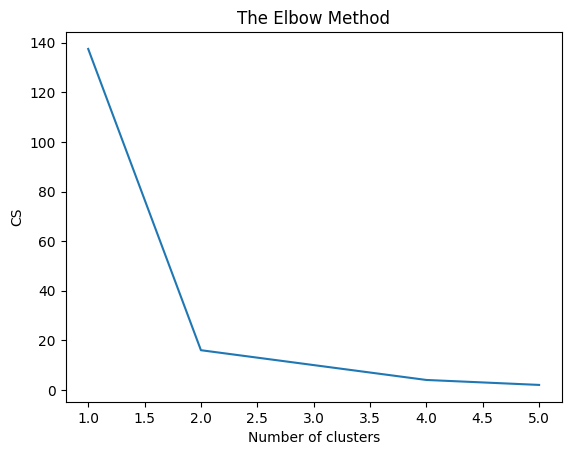

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Create sample data
X = np.array([[1,2],[1,4],[1,0],[10,2],[10,4],[10,0]])

from sklearn.cluster import KMeans

cs = []
for i in range(1, 6):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X)
    cs.append(kmeans.inertia_)

plt.plot(range(1, 6), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()


Cluster Labels: [1 1 1 0 0 0]
Centroids:
 [[10.  2.]
 [ 1.  2.]]


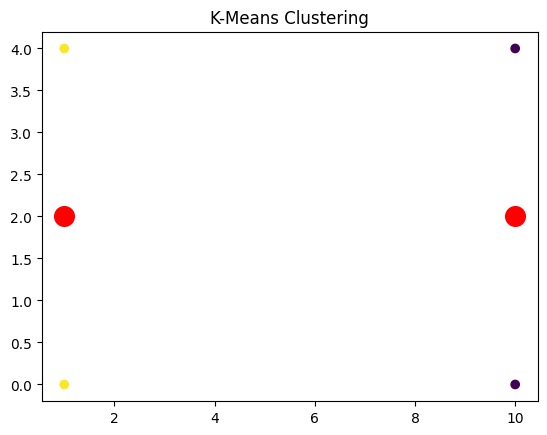

In [5]:

# Create KMeans model
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)

# Predict clusters
labels = kmeans.predict(X)

print("Cluster Labels:", labels)
print("Centroids:\n", kmeans.cluster_centers_)

# Plot
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200, c='red')
plt.title("K-Means Clustering")
plt.show()

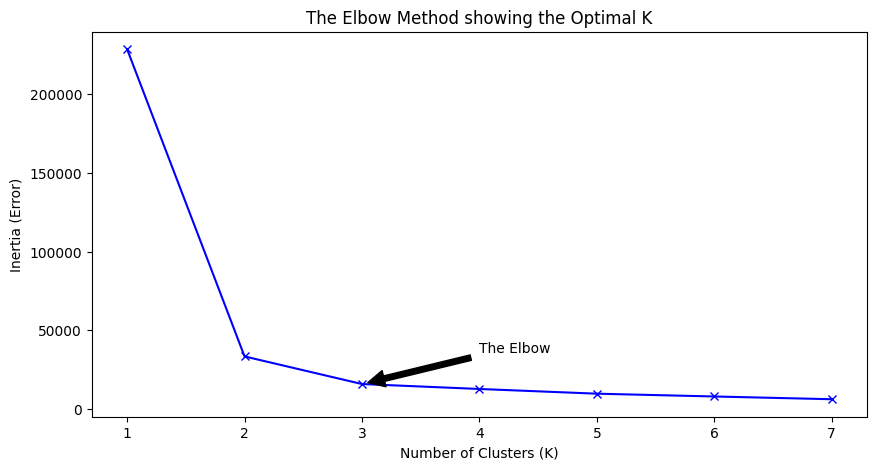

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Create the Dataset (Cricket Players)
# Features: [Runs Scored, Wickets Taken]
np.random.seed(42)
batsmen = np.random.normal([80, 5], 10, (45, 2))    # High runs, low wickets
bowlers = np.random.normal([10, 70], 10, (45, 2))    # Low runs, high wickets
all_rounders = np.full((10, 2), [50, 50])           # Your 10 "Middle" players

X = np.vstack((batsmen, bowlers, all_rounders))

# 2. The Elbow Method
inertia = []
K_range = range(1, 8)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

# 3. Plotting the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Error)')
plt.title('The Elbow Method showing the Optimal K')
plt.annotate('The Elbow', xy=(3, inertia[2]), xytext=(4, inertia[2]+20000),arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()



In [9]:
X

array([[ 8.49671415e+01,  3.61735699e+00],
       [ 8.64768854e+01,  2.02302986e+01],
       [ 7.76584663e+01,  2.65863043e+00],
       [ 9.57921282e+01,  1.26743473e+01],
       [ 7.53052561e+01,  1.04256004e+01],
       [ 7.53658231e+01,  3.42702464e-01],
       [ 8.24196227e+01, -1.41328024e+01],
       [ 6.27508217e+01, -6.22875292e-01],
       [ 6.98716888e+01,  8.14247333e+00],
       [ 7.09197592e+01, -9.12303701e+00],
       [ 9.46564877e+01,  2.74223700e+00],
       [ 8.06752820e+01, -9.24748186e+00],
       [ 7.45561728e+01,  6.10922590e+00],
       [ 6.84900642e+01,  8.75698018e+00],
       [ 7.39936131e+01,  2.08306250e+00],
       [ 7.39829339e+01,  2.35227818e+01],
       [ 7.98650278e+01, -5.57710929e+00],
       [ 8.82254491e+01, -7.20843650e+00],
       [ 8.20886360e+01, -1.45967012e+01],
       [ 6.67181395e+01,  6.96861236e+00],
       [ 8.73846658e+01,  6.71368281e+00],
       [ 7.88435172e+01,  1.98896304e+00],
       [ 6.52147801e+01, -2.19844208e+00],
       [ 7.

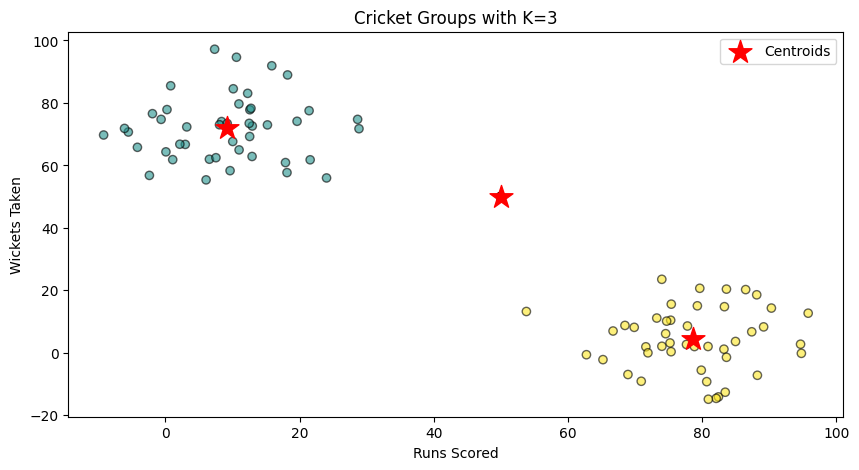

In [7]:
# 4. Final K-Means with Optimal K (K=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# 5. Visualizing the Clusters and Centroids
plt.figure(figsize=(10, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='k')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='*', label='Centroids')
plt.title(f"Cricket Groups with K={optimal_k}")
plt.xlabel("Runs Scored")
plt.ylabel("Wickets Taken")
plt.legend()
plt.show()

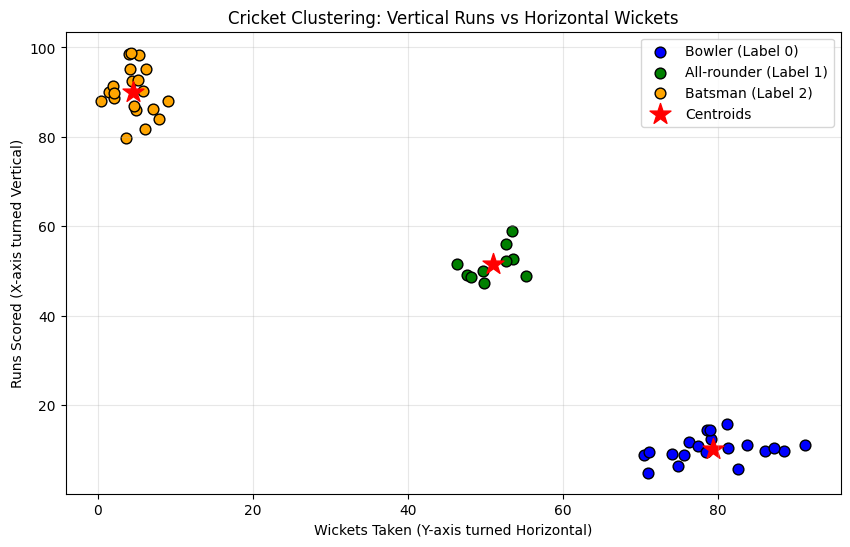

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Generating the 50-player dataset
np.random.seed(7)

# 20 Batsmen: High runs (~90), Low wickets (~5)
batsmen_data = np.random.normal(loc=[90, 5], scale=[5, 2], size=(20, 2))
# 20 Bowlers: Low runs (~10), High wickets (~80)
bowlers_data = np.random.normal(loc=[10, 80], scale=[3, 5], size=(20, 2))
# 10 All-rounders: Mid runs (~50), Mid wickets (~50)
allrounders_data = np.random.normal(loc=[50, 50], scale=[4, 4], size=(10, 2))

# Combine: Column 0 = Runs (X), Column 1 = Wickets (Y)
X = np.vstack((batsmen_data, bowlers_data, allrounders_data))

# 2. Running K-Means
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
raw_labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# 3. Custom Label Mapping Logic
# We force the labels: 0=Bowler, 1=All-rounder, 2=Batsman
mapper = {}
for i, (runs, wickets) in enumerate(centroids):
    if runs > 70:   mapper[i] = 2  # Batsman (High Runs)
    elif runs < 30: mapper[i] = 0  # Bowler (Low Runs)
    else:           mapper[i] = 1  # All-rounder (Middle)

# Apply the mapping to labels and centroids
mapped_labels = np.array([mapper[l] for l in raw_labels])
mapped_centroids = np.zeros_like(centroids)
for old_idx, new_idx in mapper.items():
    mapped_centroids[new_idx] = centroids[old_idx]

# 4. Visualization with SWAPPED AXES
# We plot Wickets on the horizontal (standard X) and Runs on the vertical (standard Y)
plt.figure(figsize=(10, 6))
colors = {0: 'blue', 1: 'green', 2: 'orange'}
names = {0: 'Bowler (Label 0)', 1: 'All-rounder (Label 1)', 2: 'Batsman (Label 2)'}

for label_id in [0, 1, 2]:
    mask = (mapped_labels == label_id)
    # Scatter(Horizontal=Wickets, Vertical=Runs)
    plt.scatter(X[mask, 1], X[mask, 0], c=colors[label_id], label=names[label_id], s=60, edgecolors='k')

# Plot Centroids (Red Stars)
plt.scatter(mapped_centroids[:, 1], mapped_centroids[:, 0], c='red', s=250, marker='*', label='Centroids')

plt.title("Cricket Clustering: Vertical Runs vs Horizontal Wickets")
plt.ylabel("Runs Scored (X-axis turned Vertical)")
plt.xlabel("Wickets Taken (Y-axis turned Horizontal)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
import numpy as np

# 1. Prepare the player data (Runs=72, Wickets=36)
# Standard format: [[Feature_1, Feature_2]]
new_player_data = np.array([[72, 36]])

# 2. Get the RAW cluster from the K-Means model
raw_category = final_model.predict(new_player_data)[0]

# 3. Use the 'mapper' we created to get your specific role (0, 1, or 2)
# This ensures 72 runs/36 wickets correctly maps to 'All-rounder'
final_category = mapper[raw_category]

# 4. Output the result
role_names = {0: "Bowler", 1: "All-rounder", 2: "Batsman"}
print(f"Stats: {new_player_data[0][0]} runs, {new_player_data[0][1]} wickets")
print(f"This player belongs to Cluster {final_category}: {role_names[final_category]}")

Stats: 72 runs, 36 wickets
This player belongs to Cluster 1: All-rounder


In [26]:
import numpy as np

# 1. Prepare the player data (Runs=72, Wickets=36)
# Standard format: [[Feature_1, Feature_2]]
new_player_data = np.array([[80, 60]])

# 2. Get the RAW cluster from the K-Means model
raw_category = final_model.predict(new_player_data)[0]

# 3. Use the 'mapper' we created to get your specific role (0, 1, or 2)
# This ensures 72 runs/36 wickets correctly maps to 'All-rounder'
final_category = mapper[raw_category]

# 4. Output the result
role_names = {0: "Bowler", 1: "All-rounder", 2: "Batsman"}
print(f"Stats: {new_player_data[0][0]} runs, {new_player_data[0][1]} wickets")
print(f"This player belongs to Cluster {final_category}: {role_names[final_category]}")

Stats: 80 runs, 60 wickets
This player belongs to Cluster 1: All-rounder


In [17]:
help(kmeans)

Help on KMeans in module sklearn.cluster._kmeans object:

class KMeans(_BaseKMeans)
 |  KMeans(
 |      n_clusters=8,
 |      *,
 |      init='k-means++',
 |      n_init='auto',
 |      max_iter=300,
 |      tol=0.0001,
 |      verbose=0,
 |      random_state=None,
 |      copy_x=True,
 |      algorithm='lloyd'
 |  )
 |
 |  K-Means clustering.
 |
 |  Read more in the :ref:`User Guide <k_means>`.
 |
 |  Parameters
 |  ----------
 |
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empiri